<a href="https://colab.research.google.com/github/joseevitor/reconhecimento_de_texto_OCR_OpenCV/blob/main/VisaoComputacional.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# OCR no Colab

In [1]:
!pip install "numpy<2.0" "opencv-python==4.6.0.66" "pytesseract==0.3.9"
!sudo apt-get install -y tesseract-ocr

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
tesseract-ocr is already the newest version (4.1.1-2.1build1).
0 upgraded, 0 newly installed, 0 to remove and 3 not upgraded.


In [2]:
import pytesseract
import numpy as np
import cv2
from google.colab.patches import cv2_imshow

In [3]:
! git clone https://github.com/sthemonica/text-recognize

fatal: destination path 'text-recognize' already exists and is not an empty directory.


In [4]:
pytesseract.__version__

'0.3.9'

In [5]:
cv2.__version__

'4.6.0'

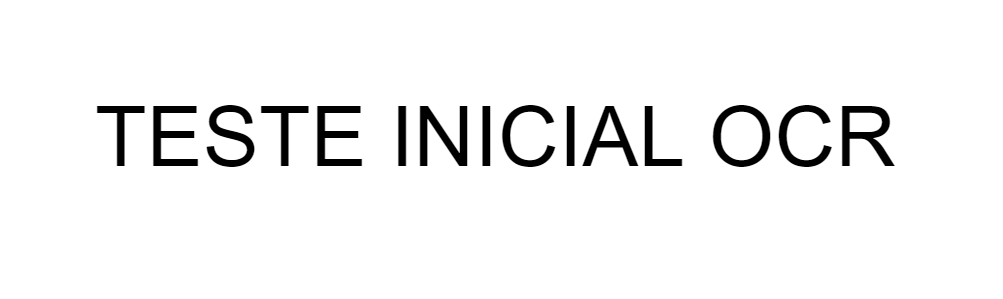

In [6]:
img = cv2.imread("/content/text-recognize/Imagens/Aula1-teste.png")
cv2_imshow(img)

In [7]:
text = pytesseract.image_to_string(img)
print(text)

TESTE INICIAL OCR



Normalmente as bibliotecas interpretam as imagens no formato RGB, que é uma versão reduzida de Red, Green e Blue, as três cores primárias que dão origem as outras cores, mas no OpenCV as entradas R e B são invertidas. SE a intenção for fazer a conexão da biblioteca com qualquer outra biblioteca para exibir a imagem, manipular ou qualquer outro tipo de ação, teria que nesse casofazer a conversão do BGR pro RGB.

# IMGs BGR

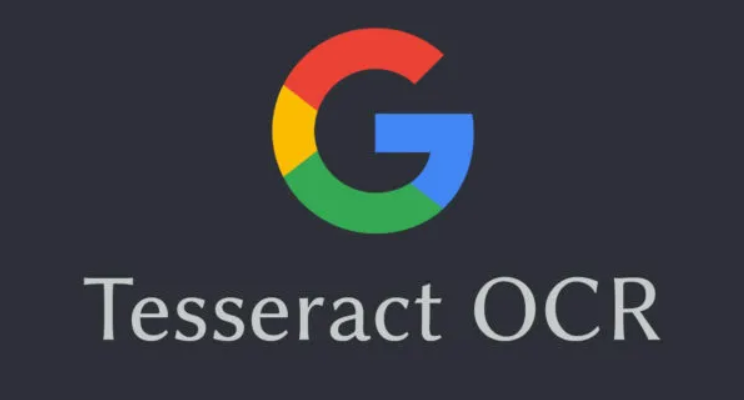

In [8]:
img = cv2.imread("/content/text-recognize/Imagens/Aula1-ocr.png")
cv2_imshow(img)

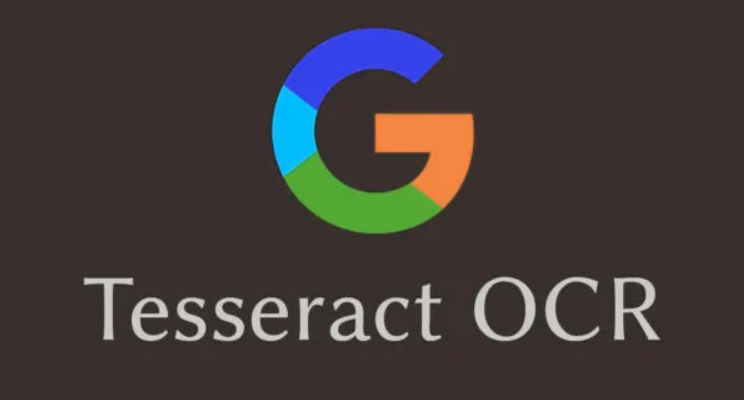

In [9]:
rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
cv2_imshow(rgb)

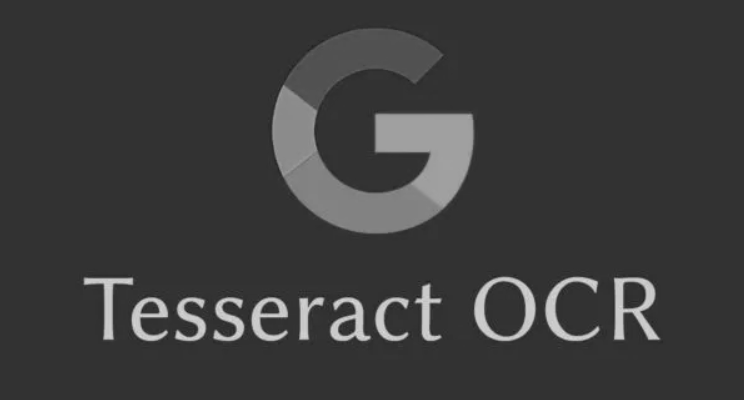

In [10]:
gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
cv2_imshow(gray)

In [11]:
text = pytesseract.image_to_string(rgb)
print(text)

c

Tesseract OCR



In [12]:
text = pytesseract.image_to_string(gray)
print(text)

Se

Tesseract OCR



# Caracteres diferentes

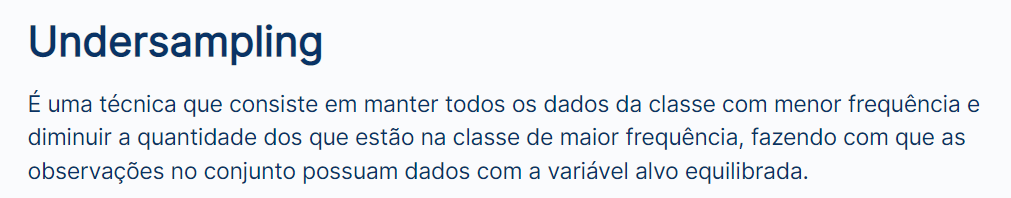

In [13]:
img = cv2.imread("/content/text-recognize/Imagens/Aula2-undersampling.png")
cv2_imshow(img)

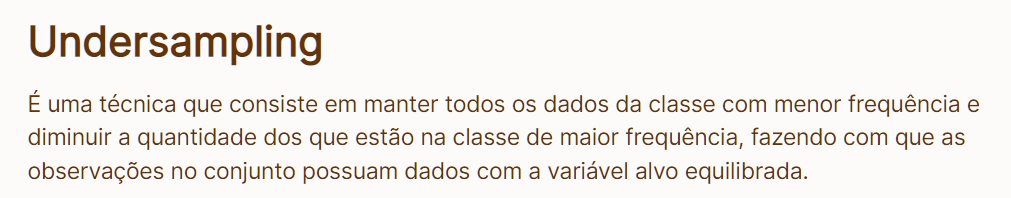

In [14]:
rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
cv2_imshow(rgb)


In [15]:
text = pytesseract.image_to_string(rgb)
print(text)

Undersampling

E uma técnica que consiste em manter todos os dados da classe com menor frequéncia e
diminuir a quantidade dos que estdo na classe de maior frequéncia, fazendo com que as
observagées no conjunto possuam dados com a variavel alvo equilibrada.



In [16]:
!tesseract --list-langs

List of available languages (2):
eng
osd


Tem que instalar o português

In [17]:
!apt-get install tesseract-ocr-por

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  tesseract-ocr-por
0 upgraded, 1 newly installed, 0 to remove and 3 not upgraded.
Need to get 856 kB of archives.
After this operation, 1,998 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 tesseract-ocr-por all 1:4.00~git30-7274cfa-1.1 [856 kB]
Fetched 856 kB in 1s (740 kB/s)
Selecting previously unselected package tesseract-ocr-por.
(Reading database ... 118243 files and directories currently installed.)
Preparing to unpack .../tesseract-ocr-por_1%3a4.00~git30-7274cfa-1.1_all.deb ...
Unpacking tesseract-ocr-por (1:4.00~git30-7274cfa-1.1) ...
Setting up tesseract-ocr-por (1:4.00~git30-7274cfa-1.1) ...


In [18]:
!tesseract --list-langs


List of available languages (3):
eng
osd
por


In [19]:
text = pytesseract.image_to_string(rgb, lang="por")
print(text)

Undersampling

É uma técnica que consiste em manter todos os dados da classe com menor frequência e
diminuir a quantidade dos que estão na classe de maior frequência, fazendo com que as
observações no conjunto possuam dados com a variável alvo equilibrada.



Como fazer o download de cada idioma, salvando em uma pasta e usando diretamento do Colab

In [20]:
!mkdir tessdata

In [21]:
!wget -O ./tessdata/por.traineddata https://github.com/tesseract-ocr/tessdata/blob/main/por.traineddata?raw=true
!wget -O ./tessdata/eng.traineddata https://github.com/tesseract-ocr/tessdata/blob/main/eng.traineddata?raw=true

--2026-07-13 13:35:36--  https://github.com/tesseract-ocr/tessdata/blob/main/por.traineddata?raw=true
Resolving github.com (github.com)... 140.82.114.4
Connecting to github.com (github.com)|140.82.114.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://github.com/tesseract-ocr/tessdata/raw/refs/heads/main/por.traineddata [following]
--2026-07-13 13:35:37--  https://github.com/tesseract-ocr/tessdata/raw/refs/heads/main/por.traineddata
Reusing existing connection to github.com:443.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/tesseract-ocr/tessdata/refs/heads/main/por.traineddata [following]
--2026-07-13 13:35:37--  https://raw.githubusercontent.com/tesseract-ocr/tessdata/refs/heads/main/por.traineddata
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.1

In [22]:
config_tesseract = "--tessdata-dir tessdata"
text = pytesseract.image_to_string(rgb, lang="por", config=config_tesseract)
print(text)

Undersampling

É uma técnica que consiste em manter todos os dados da classe com menor frequência e
diminuir a quantidade dos que estão na classe de maior frequência, fazendo com que as
observações no conjunto possuam dados com a variável alvo equilibrada.



Se eu quiser ver quais são os idiomas disponíveis posso fazer igual um comando no linux


In [23]:
!ls tessdata/

eng.traineddata  por.traineddata


# PSM

Page Segmentation Mode

In [24]:
!tesseract --help-psm

Page segmentation modes:
  0    Orientation and script detection (OSD) only.
  1    Automatic page segmentation with OSD.
  2    Automatic page segmentation, but no OSD, or OCR. (not implemented)
  3    Fully automatic page segmentation, but no OSD. (Default)
  4    Assume a single column of text of variable sizes.
  5    Assume a single uniform block of vertically aligned text.
  6    Assume a single uniform block of text.
  7    Treat the image as a single text line.
  8    Treat the image as a single word.
  9    Treat the image as a single word in a circle.
 10    Treat the image as a single character.
 11    Sparse text. Find as much text as possible in no particular order.
 12    Sparse text with OSD.
 13    Raw line. Treat the image as a single text line,
       bypassing hacks that are Tesseract-specific.


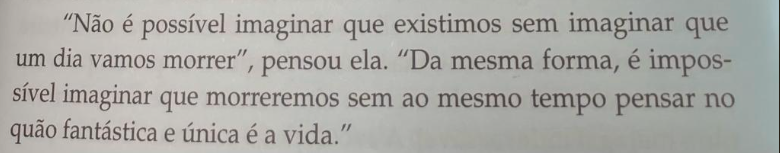

In [25]:
img = cv2.imread("/content/text-recognize/Imagens/Aula2-trecho-livro.png")
rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
cv2_imshow(rgb)

In [26]:
config_tesseract = "--tessdata-dir tessdata"
text = pytesseract.image_to_string(rgb, lang="por", config=config_tesseract)
print(text)

“Não é possível imaginar que existimos sem imaginar que
um dia vamos morrer”, pensou ela. “Da mesma forma, é impos-
sível imaginar que morreremos sem ao mesmo tempo pensar no
quão fantástica e única é a vida.”



Dá pra tipar o psm utilizado, pra garantir que o OpenCV vai interpretar na maneira "correta", de acordo com as classificações do Page Segmentation Mode.

In [27]:
config_tesseract = "--tessdata-dir tessdata --psm 6"
text = pytesseract.image_to_string(rgb, lang="por", config=config_tesseract)
print(text)

“Não é possível imaginar que existimos sem imaginar que
um dia vamos morrer”, pensou ela. “Da mesma forma, é impos-
sível imaginar que morreremos sem ao mesmo tempo pensar no
quão fantástica e única é a vida.”



In [28]:
config_tesseract = "--tessdata-dir tessdata --psm 7"
text = pytesseract.image_to_string(rgb, lang="por", config=config_tesseract)
print(text)

In [29]:
config_tesseract = "--tessdata-dir tessdata --psm 8"
text = pytesseract.image_to_string(rgb, lang="por", config=config_tesseract)
print(text)

ªfâ%êããããââª%%?ªííÉ:D;Z:Én:gíríãrgâgíie::ugfâ|



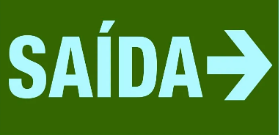

SAÍDAS



In [30]:
img = cv2.imread("/content/text-recognize/Imagens/Aula2-Saida.png")
rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
config_tesseract = "--tessdata-dir tessdata --psm 7"
text = pytesseract.image_to_string(rgb, lang="por", config=config_tesseract)
cv2_imshow(rgb)
print(text)

ESTE MODO É BASTANTE USADO PARA PLACAS DE CARRO

# Biblioteca Pillow

In [31]:
from PIL import Image
import matplotlib.pyplot as plt

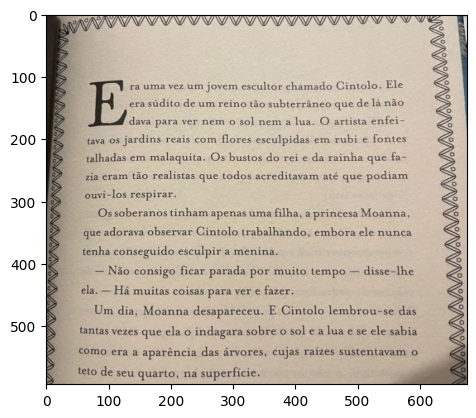

In [32]:
img = Image.open("/content/text-recognize/Imagens/Aula2-livro.png")
plt.imshow(img);

In [33]:
print(pytesseract.image_to_osd(img))

Page number: 0
Orientation in degrees: 0
Rotate: 0
Orientation confidence: 0.93
Script: Latin
Script confidence: 2.46



OFF TOPIC, ABAIXO SEGUE UM EXEMPLO DE O QUE FAZER SE EU QUISER CARREGAR, GIRAR 45 GRAUS E DEPOIS ABRIR UMA IMAGEM

In [34]:
from PIL import Image
with Image.open("image.jpg") as im:
  im.rotate(45).show()

# CERTAMENTE AQUI N VAI RODAR PQ É MAIS UMA CURIOSIDADE

FileNotFoundError: [Errno 2] No such file or directory: 'image.jpg'

CONTINUANDO...

# Selecionando textos

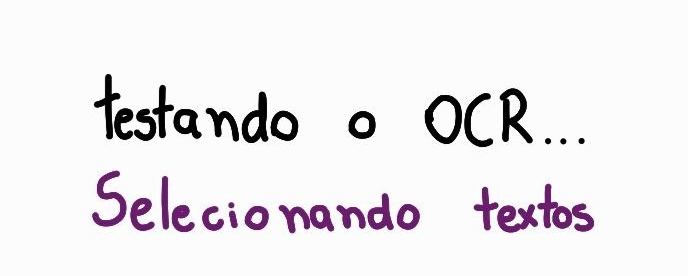

In [35]:
img = cv2.imread("/content/text-recognize/Imagens/Aula3-testando.png")
rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
cv2_imshow(rgb)

In [37]:
from pytesseract import Output

In [38]:
config_tesseract = "--tessdata-dir tessdata"
result = pytesseract.image_to_data(rgb, config=config_tesseract, lang="por", output_type=Output.DICT)
result

{'level': [1, 2, 3, 4, 5, 5, 5, 4, 5, 5],
 'page_num': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
 'block_num': [0, 1, 1, 1, 1, 1, 1, 1, 1, 1],
 'par_num': [0, 0, 1, 1, 1, 1, 1, 1, 1, 1],
 'line_num': [0, 0, 0, 1, 1, 1, 1, 2, 2, 2],
 'word_num': [0, 0, 0, 0, 1, 2, 3, 0, 1, 2],
 'left': [0, 92, 92, 94, 94, 348, 425, 92, 92, 474],
 'top': [0, 74, 74, 74, 74, 111, 88, 171, 171, 184],
 'width': [688, 502, 502, 491, 204, 28, 160, 502, 328, 120],
 'height': [276, 159, 159, 73, 69, 28, 59, 62, 62, 49],
 'conf': ['-1', '-1', '-1', '-1', 63, 90, 48, '-1', 85, 77],
 'text': ['',
  '',
  '',
  '',
  'Testando',
  'o',
  'OCR..',
  '',
  'Selecionando',
  'textos']}

In [39]:
min_conf = 40 #@param {type: "slider", max: 100, min: 0}

# Caixa delimitadora

In [49]:
def text_box(result, img, color = (255, 100, 0)):
  x = result['left'][i]
  y = result['top'][i]
  w = result['width'][i]
  h = result['height'][i]

  cv2.rectangle(img, (x, y), (x + w, y + h), color, 2)

  return x, y, img

In [50]:
len(result['text'])

10

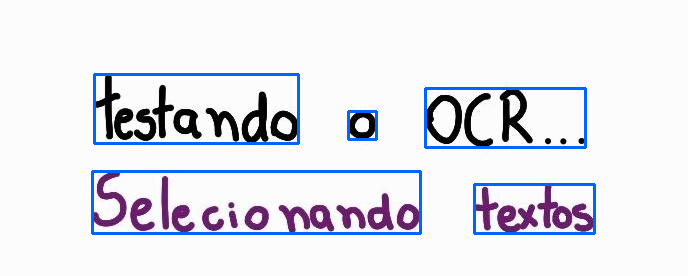

In [51]:
from numpy.lib.type_check import imag
img_copy = rgb.copy()
for i in range(len(result['text'])):
  confidence = int(result['conf'][i])
  if confidence > min_conf:
    x, y, img = text_box(result, img_copy)
cv2_imshow(img_copy)

In [52]:
text_box(result, rgb)

(474,
 184,
 array([[[252, 252, 252],
         [252, 252, 252],
         [252, 252, 252],
         ...,
         [252, 252, 252],
         [252, 252, 252],
         [252, 252, 252]],
 
        [[252, 252, 252],
         [252, 252, 252],
         [252, 252, 252],
         ...,
         [252, 252, 252],
         [252, 252, 252],
         [252, 252, 252]],
 
        [[252, 252, 252],
         [252, 252, 252],
         [252, 252, 252],
         ...,
         [252, 252, 252],
         [252, 252, 252],
         [252, 252, 252]],
 
        ...,
 
        [[252, 252, 252],
         [252, 252, 252],
         [252, 252, 252],
         ...,
         [252, 252, 252],
         [252, 252, 252],
         [252, 252, 252]],
 
        [[252, 252, 252],
         [252, 252, 252],
         [252, 252, 252],
         ...,
         [252, 252, 252],
         [252, 252, 252],
         [252, 252, 252]],
 
        [[252, 252, 252],
         [252, 252, 252],
         [252, 252, 252],
         ...,
         [252, 2

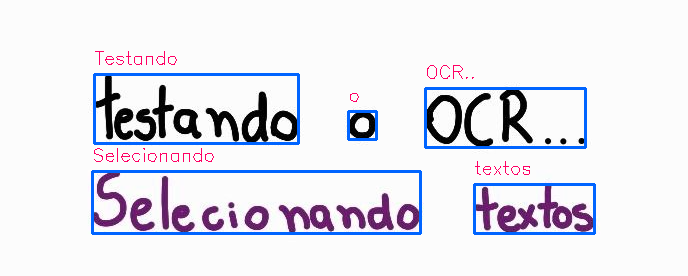

In [60]:
from numpy.lib.type_check import imag
img_copy = rgb.copy()
for i in range(len(result['text'])):
  confidence = int(result['conf'][i])
  if confidence > min_conf:
    x, y, img = text_box(result, img_copy)
    text = result['text'][i]
    cv2.putText(img_copy, text, (x, y - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (100, 0, 255)) #como está em BGR é importante lembrar que o 255 é o R



cv2_imshow(img_copy)

# Fontes

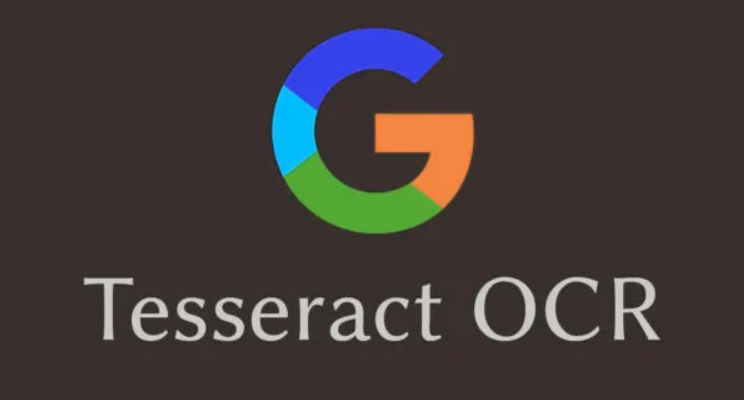

In [61]:
img = cv2.imread("/content/text-recognize/Imagens/Aula1-ocr.png")
rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
cv2_imshow(rgb)

In [62]:
config_tesseract = "--tessdata-dir tessdata"
result = pytesseract.image_to_data(rgb, config=config_tesseract, lang="por", output_type=Output.DICT)
result

{'level': [1, 2, 3, 4, 5, 2, 3, 4, 5, 5],
 'page_num': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
 'block_num': [0, 1, 1, 1, 1, 2, 2, 2, 2, 2],
 'par_num': [0, 0, 1, 1, 1, 0, 1, 1, 1, 1],
 'line_num': [0, 0, 0, 1, 1, 0, 0, 1, 1, 1],
 'word_num': [0, 0, 0, 0, 1, 0, 0, 0, 1, 2],
 'left': [0, 272, 272, 272, 272, 84, 84, 84, 84, 474],
 'top': [0, 28, 28, 28, 28, 277, 277, 277, 278, 277],
 'width': [744, 202, 202, 202, 202, 576, 576, 576, 357, 186],
 'height': [400, 205, 205, 205, 205, 64, 64, 64, 63, 64],
 'conf': ['-1', '-1', '-1', '-1', 91, '-1', '-1', '-1', 91, 90],
 'text': ['', '', '', '', 'G', '', '', '', 'Tesseract', 'OCR']}

In [63]:
from PIL import ImageFont, ImageDraw, Image
font = "/content/text-recognize/Imagens/calibri.ttf"

# Função para as fontes

In [64]:
def write_text(text, x, y, img, font, size_text=32):
  font = ImageFont.truetype(font, size_text)
  img_pil = Image.fromarray(img)
  draw = ImageDraw.Draw(img_pil)
  draw.text((x, y - size_text), text, font = font)
  img = np.array(img_pil)
  return img

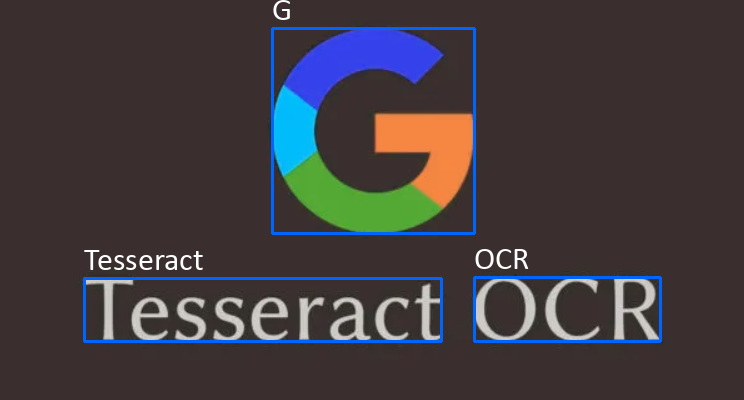

In [65]:
img_copy = rgb.copy()
for i in range(len(result["text"])):
  confidence = int(result["conf"][i])
  if confidence > min_conf:
    x, y, img = text_box(result, img_copy)

    text = result['text'][i]

    img_copy = write_text(text, x, y, img_copy, font)

cv2_imshow(img_copy)

EXEMPLO DE COMO SALVAR IMAGENS SEM PRECISAR CRIAR DIRETORIOS

In [66]:
import os
os.makedirs("images_tesseract", exist_ok=True)

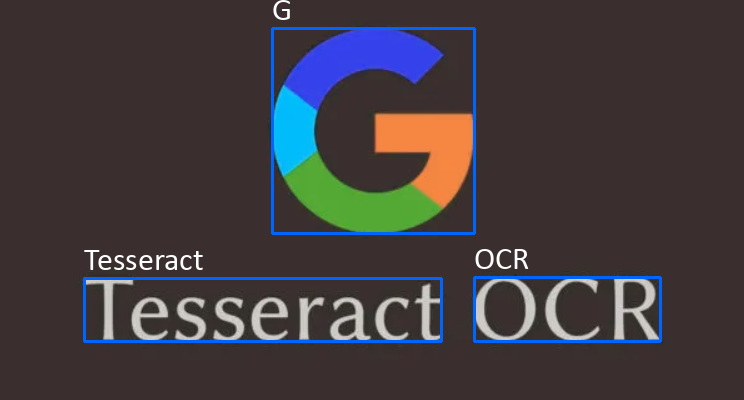

In [67]:
cv2_imshow(img_copy)

In [68]:
logo_tesseract = "/content/images_tesseract/logo_tesseract.png"

In [69]:
cv2.imwrite(logo_tesseract, img_copy)

True

# Como conseguir informações das imagens